- Repetindo a mesma arquitetura/pipeline do modelo xgb:

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import itertools
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# dataframe vindo do notebook anterior
caminho_arquivo = 'nfl_features_ml_2021_2025.parquet'

try:
    df_ml = pd.read_parquet(caminho_arquivo)
    print(f"Dataset carregado com sucesso! Total de jogos: {len(df_ml)}")
except Exception as e:
    print("Tentando carregar CSV como fallback...")
    df_ml = pd.read_csv('nfl_features_ml_2021_2025.csv')

Dataset carregado com sucesso! Total de jogos: 1339


In [ ]:
# definindo os blocos simétricos (Mandante e Visitante SEMPRE alinhados)
opcoes_pts = [
    [], # sem pontos
    ['home_offense_pts_last3', 'home_defense_pts_last3', 'away_offense_pts_last3', 'away_defense_pts_last3'], # só Last3
    ['home_offense_pts_season', 'home_defense_pts_season', 'away_offense_pts_season', 'away_defense_pts_season'], # só Season
    ['home_offense_pts_last3', 'home_defense_pts_last3', 'away_offense_pts_last3', 'away_defense_pts_last3',
     'home_offense_pts_season', 'home_defense_pts_season', 'away_offense_pts_season', 'away_defense_pts_season'] # ambos
]

opcoes_ypp = [
    [], 
    ['home_yards_per_play_last3', 'away_yards_per_play_last3'], 
    ['home_yards_per_play_season', 'away_yards_per_play_season'], 
    ['home_yards_per_play_last3', 'away_yards_per_play_last3', 'home_yards_per_play_season', 'away_yards_per_play_season']
]

opcoes_turnovers = [
    [], 
    ['home_turnovers_last3', 'away_turnovers_last3'], 
    ['home_turnovers_season', 'away_turnovers_season'], 
    ['home_turnovers_last3', 'away_turnovers_last3', 'home_turnovers_season', 'away_turnovers_season']
]

opcoes_yards = [
    [], 
    ['home_total_yards_last3', 'away_total_yards_last3'], 
    ['home_total_yards_season', 'away_total_yards_season'], 
    ['home_total_yards_last3', 'away_total_yards_last3', 'home_total_yards_season', 'away_total_yards_season']
]

# separação cronológica
df_train = df_ml[df_ml['season'] < 2025]
df_test = df_ml[df_ml['season'] == 2025]
y_train = df_train['target']
y_test = df_test['target']

resultados = []

print("Iniciando varredura de 256 combinações lógicas. Isso pode levar um minutinho...")

# gerando o produto cartesiano (Todas as combinações possíveis entre os blocos)
for combo in itertools.product(opcoes_pts, opcoes_ypp, opcoes_turnovers, opcoes_yards):
    pts_feats, ypp_feats, turn_feats, yards_feats = combo
    
    # junta todas as features ativas nesta combinação
    features_ativas = pts_feats + ypp_feats + turn_feats + yards_feats
    
    # ignora se a combinação estiver 100% vazia
    if len(features_ativas) == 0:
        continue
        
    # preparando descrições para a tabela final
    desc_pts = "Ambos" if len(pts_feats) == 8 else ("Season" if "season" in str(pts_feats) else ("Last3" if "last3" in str(pts_feats) else "Desligado"))
    desc_ypp = "Ambos" if len(ypp_feats) == 4 else ("Season" if "season" in str(ypp_feats) else ("Last3" if "last3" in str(ypp_feats) else "Desligado"))
    desc_turn = "Ambos" if len(turn_feats) == 4 else ("Season" if "season" in str(turn_feats) else ("Last3" if "last3" in str(turn_feats) else "Desligado"))
    desc_yards = "Ambos" if len(yards_feats) == 4 else ("Season" if "season" in str(yards_feats) else ("Last3" if "last3" in str(yards_feats) else "Desligado"))
    
    # separando Treino e Teste para esta combinação específica
    X_train = df_train[features_ativas]
    X_test = df_test[features_ativas]
    
    # treinando uma Random Forest base
    rf_grid = RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        random_state=42
    )
    rf_grid.fit(X_train, y_train)
    
    # prevendo e medindo a Acurácia base (sem o filtro de toss-up)
    preds = rf_grid.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    # salvando os resultados
    resultados.append({
        'Pts': desc_pts,
        'YPP': desc_ypp,
        'Turnovers': desc_turn,
        'Jardas': desc_yards,
        'Qtd_Features': len(features_ativas),
        'Acuracia_Bruta': acc,
        'Features_Lista': features_ativas
    })

# exibindo o Top 10 Estratégias
df_ranking = pd.DataFrame(resultados).sort_values(by='Acuracia_Bruta', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 COMBINAÇÕES DE FEATURES (RANDOM FOREST) ===")
display(df_ranking[['Pts', 'YPP', 'Turnovers', 'Jardas', 'Qtd_Features', 'Acuracia_Bruta']].head(10))

Iniciando varredura de 256 combinações lógicas. Isso pode levar um minutinho...

=== TOP 10 COMBINAÇÕES DE FEATURES (RANDOM FOREST) ===


,Pts,YPP,Turnovers,Jardas,Qtd_Features,Acuracia_Bruta
0,Ambos,Desligado,Desligado,Desligado,8,0.627306
1,Ambos,Desligado,Last3,Desligado,10,0.623616
2,Desligado,Desligado,Last3,Last3,4,0.619926
3,Ambos,Desligado,Ambos,Desligado,12,0.619926
4,Season,Desligado,Desligado,Desligado,4,0.616236
5,Last3,Season,Ambos,Last3,12,0.616236
6,Last3,Desligado,Ambos,Desligado,8,0.616236
7,Last3,Desligado,Last3,Desligado,6,0.612546
8,Ambos,Ambos,Season,Desligado,14,0.612546
9,Season,Desligado,Last3,Desligado,6,0.608856


- Apesar da linha 0 ter a melhor acurácia, ela não foi escolhida, pois em testes posteriores ela estava dando resultados piores. Então ficou decidido pela linha 1.

In [ ]:
# definindo as features da linha 1 
features_tuning_rf = [
    # Pts (Ambos: EWMA/Last3 + Season)
    'home_offense_pts_last3', 'home_defense_pts_last3', 
    'home_offense_pts_season', 'home_defense_pts_season',
    'away_offense_pts_last3', 'away_defense_pts_last3', 
    'away_offense_pts_season', 'away_defense_pts_season',

    # Turnovers (Apenas o Momento Recente / EWMA)
    'home_turnovers_last3', 
    'away_turnovers_last3'
]

# separando Treino e Teste
X_train_rf = df_train[features_tuning_rf]
y_train_rf = df_train['target']
X_test_rf = df_test[features_tuning_rf]
y_test_rf = df_test['target']

# o gridsearch específico pro RF
param_grid_rf = {
    'max_depth': [5, 7, 9],               # florestas precisam de árvores mais profundas que o XGB
    'n_estimators': [100, 200, 300],      # quantidade de árvores na floresta
    'min_samples_leaf': [2, 4, 6],        # parametro ante-overfitting: mínimo de jogos numa folha para ela existir
    'max_features': ['sqrt', 'log2']      # como o algoritmo sorteia as colunas em cada quebra
}

print("Iniciando o GridSearch da Random Forest...")

# configurando e treinando
rf_base = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid_rf, 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1, 
    verbose=1
)

grid_search_rf.fit(X_train_rf, y_train_rf)

# extraindo a vencedora
melhor_rf = grid_search_rf.best_estimator_
melhores_params_rf = grid_search_rf.best_params_

print("\n=== RESULTADO DA OTIMIZAÇÃO (RANDOM FOREST) ===")
print(f"Melhores Hiperparâmetros:\n{melhores_params_rf}")

# testando a acurácia bruta
preds_rf = melhor_rf.predict(X_test_rf)
acc_rf = accuracy_score(y_test_rf, preds_rf)
print(f"\nAcurácia Bruta no Teste (2025): {acc_rf:.4f}")

Iniciando o GridSearch da Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

=== RESULTADO DA OTIMIZAÇÃO (RANDOM FOREST) ===
Melhores Hiperparâmetros:
{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}

Acurácia Bruta no Teste (2025): 0.6199


In [23]:
features = [
    # Pts (Ambos: EWMA/Last3 + Season)
    'home_offense_pts_last3', 'home_defense_pts_last3', 
    'home_offense_pts_season', 'home_defense_pts_season',
    'away_offense_pts_last3', 'away_defense_pts_last3', 
    'away_offense_pts_season', 'away_defense_pts_season',
    
    # Turnovers (Apenas o Momento Recente / EWMA)
    'home_turnovers_last3', 
    'away_turnovers_last3'
]

# separação cronológica (Treino = 2021-2024, Teste = 2025)
df_train = df_ml[df_ml['season'] < 2025]
df_test = df_ml[df_ml['season'] == 2025]

X_train, y_train = df_train[features], df_train['target']
X_test, y_test = df_test[features], df_test['target']

In [24]:
# treinando a Random Forest otimizada
rf = RandomForestClassifier(
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=2,
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [25]:
# as previsões "Duras" (0 ou 1) para Acurácia, Precisão, Recall e F1
rf_preds = rf.predict(X_test)

# as previsões de "Probabilidade" para o ROC AUC
# o [:, 1] pega apenas a probabilidade de a classe ser 1 (Vitória do Mandante)
rf_probs = rf.predict_proba(X_test)[:, 1]

In [26]:
def imprimir_raio_x_modelo(nome_modelo, y_true, y_pred, y_prob):
    print(f"=== {nome_modelo} ===")
    print(f"Acurácia : {accuracy_score(y_true, y_pred):.2%}")
    print(f"Precisão : {precision_score(y_true, y_pred):.2%}")
    print(f"Recall   : {recall_score(y_true, y_pred):.2%}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.2%}")
    
    # ROC AUC exige que as duas classes (0 e 1) estejam presentes no y_true para não dar erro
    if len(np.unique(y_true)) > 1:
        print(f"ROC AUC  : {roc_auc_score(y_true, y_prob):.2%}")
    else:
        print(f"ROC AUC  : N/A (Apenas uma classe no filtro)")
    print("=" * 40)

In [27]:
# exibindo os resultados do modelo em todos os jogos (Acurácia Bruta)
imprimir_raio_x_modelo("Random Forest (Acurácia Bruta - Sem Filtro)", y_test, rf_preds, rf_probs)

=== Random Forest (Acurácia Bruta - Sem Filtro) ===
Acurácia : 61.99%
Precisão : 63.69%
Recall   : 68.49%
F1-Score : 66.01%
ROC AUC  : 66.44%


In [28]:
# definindo as fronteiras do Toss-Up (jogos imprevisíveis)
limite_inferior = 0.45
limite_superior = 0.55

def aplicar_filtro_tossup(nome_modelo, y_true, probs):
    y_true_array = np.array(y_true)
    probs_array = np.array(probs)
    
    # filtro: Pega só onde o modelo tem convicção (< 45% ou > 55%)
    jogos_confiantes = (probs_array < limite_inferior) | (probs_array > limite_superior)
    
    y_true_filtrado = y_true_array[jogos_confiantes]
    probs_filtrado = probs_array[jogos_confiantes]
    
    # gera a previsão dura (0 ou 1) para as métricas
    previsoes_finais = (probs_filtrado > 0.50).astype(int)
    
    total_jogos = len(y_true)
    jogos_apostados = len(y_true_filtrado)
    jogos_ignorados = total_jogos - jogos_apostados
    
    print(f"\n=== {nome_modelo} (Filtro Toss-Up 45%-55%) ===")
    
    if jogos_apostados == 0:
        print("O modelo não teve confiança em NENHUM jogo!")
        print("-" * 40)
        return
        
    print(f"Jogos Avaliados: {jogos_apostados}/{total_jogos} | Ignorados: {jogos_ignorados} ({jogos_ignorados/total_jogos:.1%})")
    
    # chama a função reaproveitada (passando um texto descritivo para o título interno)
    imprimir_raio_x_modelo("Métricas Filtradas", y_true_filtrado, previsoes_finais, probs_filtrado)

# aplica a função apenas para a Random Forest
aplicar_filtro_tossup("Random Forest", y_test, rf_probs)


=== Random Forest (Filtro Toss-Up 45%-55%) ===
Jogos Avaliados: 193/271 | Ignorados: 78 (28.8%)
=== Métricas Filtradas ===
Acurácia : 64.77%
Precisão : 65.22%
Recall   : 72.82%
F1-Score : 68.81%
ROC AUC  : 69.85%


=== RANKING DE IMPORTÂNCIA DAS FEATURES (Random Forest) ===


,Feature,Importancia
0,away_offense_pts_season,0.152446
1,home_offense_pts_season,0.142399
2,home_offense_pts_last3,0.114248
3,away_offense_pts_last3,0.096799
4,away_turnovers_last3,0.090608
5,away_defense_pts_last3,0.084455
6,home_defense_pts_last3,0.084327
7,away_defense_pts_season,0.081052
8,home_turnovers_last3,0.080890
9,home_defense_pts_season,0.072776


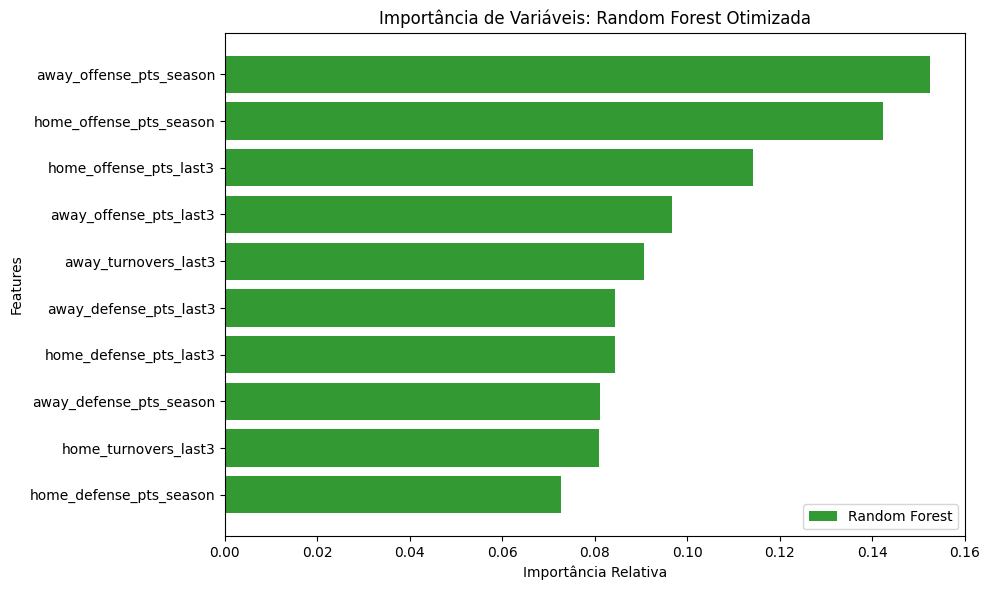

In [ ]:
# garante que tem a lista com o nome de todas as colunas de treino
features_names = [col for col in X_train.columns]

# extraindo a importância da Random Forest
importancia_rf = rf.feature_importances_

# montando um DataFrame para facilitar a visualização e ordenação
df_importancia = pd.DataFrame({
    'Feature': features_names,
    'Importancia': importancia_rf
})

# ordenando pela importância
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).reset_index(drop=True)

print("=== RANKING DE IMPORTÂNCIA DAS FEATURES (Random Forest) ===")
display(df_importancia)

# gráfico visual para achar os protagonistas
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color='green', alpha=0.8, label='Random Forest')
plt.xlabel('Importância Relativa')
plt.ylabel('Features')
plt.title('Importância de Variáveis: Random Forest Otimizada')
plt.gca().invert_yaxis() # deixa o que é mais importante no topo
plt.legend()
plt.tight_layout()
plt.show()